In [ ]:
from typing import Iterator
from torch.utils.data import DataLoader, SequentialSampler, Dataset

class ExampleDataset(Dataset):
    def __init__(self, size):
        self.data = list(range(size))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = ExampleDataset(100)
from torch.utils.data import RandomSampler

sampler = RandomSampler(dataset)
dataloader = DataLoader(dataset, sampler=sampler, batch_size=4, drop_last=True)



class MyDataLoader(DataLoader):
    def __init__(self, dataset, batch_size = 1, shuffle = None, sampler = None, batch_sampler = None, num_workers = 0, collate_fn = None, pin_memory = False, drop_last = False, timeout = 0, worker_init_fn = None, multiprocessing_context=None, generator=None, *, prefetch_factor = None, persistent_workers = False, pin_memory_device = ""):
        super().__init__(dataset, batch_size, shuffle, sampler, batch_sampler, num_workers, collate_fn, pin_memory, drop_last, timeout, worker_init_fn, multiprocessing_context, generator, prefetch_factor=prefetch_factor, persistent_workers=persistent_workers, pin_memory_device=pin_memory_device)


import math
import torch
from torch.utils.data import Sampler

class CustomDistributedSampler(Sampler, Iterator):
    def __init__(self, dataset, n_workers=None, rank=None, shuffle=True, seed=0):
        self.dataset_size = len(dataset)
        self.n_workers = n_workers
        self.rank = rank
        self.shuffle = shuffle
        self.seed = seed
        
        self.samples_per_worker = self.dataset_size // self.n_workers

        self.total_size = self.samples_per_worker * self.n_workers

    def __next__(self):
        return next(self.indeces_iters[self.rank])

    def __len__(self):
        return self.samples_per_worker
    
    def __iter__(self):
        return self
    
    def init_iters(self):
        if self.shuffle:
            g = torch.Generator()
            g.manual_seed(self.seed)
            indices = torch.randperm(self.dataset_size, generator=g).tolist()
        else:
            indices = list(range(self.dataset_size))

        for rank in range(self.n_workers):
            start = rank * self.samples_per_worker
            end = start + self.samples_per_worker
            worker_indeces = indices[start:end]
            
            self.indeces_iters = iter(worker_indeces)


    def set_epoch(self, epoch):
        self.seed = self.seed + epoch



In [1]:
import json
import pandas as pd
import os
def gen_dataframe(s):
    l = []
    for fol in os.listdir(s):
        for folder in os.listdir(os.path.join(s, fol)):
            folder = os.path.join(s, fol, folder)
            if os.path.isdir(folder):
                with open(os.path.join(folder, "result.json"), "r") as f:
                    try:    
                        res = json.load(f)
                    except:
                        continue

                res.pop("config")
                with open(os.path.join(folder, "params.json"), "r") as f:
                    params = json.load(f)
                
                for k, v in params.items():
                    res[f"config/{k}"] = v

                l.append(res)
    df = pd.DataFrame(l)
    # df.to_pickle(os.path.join(s, "analysis_results.pkl"))
    return df
    

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

def hyper_params_heatmap(results, param_1_name, param_2_name, log_scale_1=True, 
                         log_scale_2=True, metric="val_acc", mode="max", log_metric=False):
    x = results[f"config/{param_1_name}"]
    y = results[f"config/{param_2_name}"]

    if log_scale_1:
        x = np.log10(x)
        param_1_name = "Exponent of: " + param_1_name
    if log_scale_2:
        y = np.log10(y)
        param_2_name = "Exponent of: " + param_2_name

    val = results[metric] 

    if log_metric:
        val = np.log(val)

    inter = LinearNDInterpolator((x, y), val)

    x_int = np.linspace(x.min(), x.max(), 1000)
    y_int = np.linspace(y.min(), y.max(), 1000)
    mesh = np.meshgrid(x_int, y_int)
    inter_val = inter(mesh)

    plt.imshow(inter_val, extent=[x_int[0], x_int[-1], y_int[0], y_int[-1]], origin="lower", aspect="auto")
    plt.colorbar()

    opt_ind = np.argmax(val) if mode == "max" else np.argmin(val)
    # plt.scatter(x, y)
    plt.scatter(x[opt_ind], y[opt_ind], c="r", marker="*", label=f"Optimum: {val[opt_ind]}")

    plt.xlabel(param_1_name)
    plt.ylabel(param_2_name)
    
    if log_metric:
        plt.title(f"Heatmap for: log({metric})")
    else:
        plt.title(f"Heatmap for: {metric}")
    plt.legend()

folder = r"Results2\slow_mo_momentum"#r"Results2\mini_batch_adamw\tune_distributed_learning_2025-01-19_22-36-14"
df = gen_dataframe(folder)

# hyper_params_heatmap(df, "local_opt.lr", "local_opt.weight_decay", True, True)#, "val_loss", "min", True)
# hyper_params_heatmap(df, "local_batch_size", "local_opt.lr", False, True, "val_acc", "max", False)
# hyper_params_heatmap(df, "n_workers", "n_local_steps", False, False, "test_acc")
# plt.savefig(os.path.join(folder, "heatmap_plot_loss.png"))

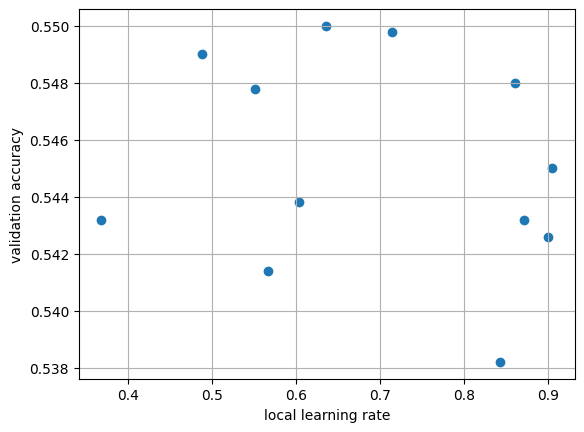

In [16]:
plt.scatter(df["config/global_opt.momentum"], df["val_acc"])
# plt.xscale("log")
plt.xlabel("local learning rate")
plt.ylabel("validation accuracy")
# opt_ind = np.argmax(df["val_acc"])
# plt.scatter(x, y)
# plt.scatter(df["config/local_opt.lr"][opt_ind], df["val_acc"][opt_ind], c="r", marker="*", label=f"Optimum: {df["val_acc"][opt_ind]}")
plt.grid()

In [12]:
df.sort_values("val_acc", ascending=False)

,val_loss,val_acc,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,...,config/global_optimizer_class,config/local_batch_size,config/local_opt.lr,config/local_optimizer_class,config/n_epochs,config/n_local_steps,config/n_workers,config/scheduler.per_warmup_epochs,config/scheduler_class,config/test_mode
4,2.268906,0.4716,1737513124,None,False,1,fc397_00004,2025-01-22_03-32-04,1288.195899,1288.195899,...,<class 'optimizers.DoNothing'>,64,0.000908,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
8,2.440034,0.4704,1737518158,None,False,1,fc397_00008,2025-01-22_04-55-58,1291.342588,1291.342588,...,<class 'optimizers.DoNothing'>,64,0.001503,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
3,2.184798,0.4558,1737511831,None,False,1,fc397_00003,2025-01-22_03-10-31,1292.035538,1292.035538,...,<class 'optimizers.DoNothing'>,64,0.000587,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
5,2.161785,0.4548,1737514419,None,False,1,fc397_00005,2025-01-22_03-53-39,1289.369143,1289.369143,...,<class 'optimizers.DoNothing'>,64,0.000482,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
1,2.278266,0.4110,1737509237,None,False,1,fc397_00001,2025-01-22_02-27-17,1289.635404,1289.635404,...,<class 'optimizers.DoNothing'>,64,0.000263,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
0,2.429139,0.3868,1737507943,None,False,1,fc397_00000,2025-01-22_02-05-43,1291.117870,1291.117870,...,<class 'optimizers.DoNothing'>,64,0.000174,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
6,2.681980,0.3576,1737515714,None,False,1,fc397_00006,2025-01-22_04-15-14,1290.294000,1290.294000,...,<class 'optimizers.DoNothing'>,64,0.010669,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
11,3.530408,0.1814,1737522106,None,False,1,fc397_00011,2025-01-22_06-01-46,1289.678337,1289.678337,...,<class 'optimizers.DoNothing'>,64,0.000021,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
2,4.216686,0.0560,1737510533,None,False,1,fc397_00002,2025-01-22_02-48-53,1290.637384,1290.637384,...,<class 'optimizers.DoNothing'>,64,0.000002,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
9,4.364537,0.0384,1737519454,None,False,1,fc397_00009,2025-01-22_05-17-34,1290.823091,1290.823091,...,<class 'optimizers.DoNothing'>,64,0.000002,<class 'optimizers.LAMB'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False


In [11]:
import statsmodels.api as sm


def control_for(df, name, metric, log=False):
    
    coeffs = sm.OLS(df[metric], sm.add_constant(df[])).fit().params

    return df[metric] + coeffs[f"config/{name}"] * (df[f"config/{name}"].mean() - df[f"config/{name}"])


plt.scatter(df["config/n_local_steps"], control_for(df, "n_workers", "val_loss"))

In [6]:
import numpy as np
np.random.permutation(10)

array([7, 4, 5, 6, 3, 0, 8, 1, 2, 9], dtype=int32)

In [ ]:
df.filter(["config/local_opt.lr", "config/local_opt.weight_decay", "val_loss"]).sort_values("val_loss")#.sort_values("val_acc", ascending=False)

In [8]:
[2**i for i in range(1, 9)]

[2, 4, 8, 16, 32, 64, 128, 256]